Final Training Accuracy: 99.88%
Testing Accuracy: 98.55%

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time
import os

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    auc,
    matthews_corrcoef,
    cohen_kappa_score,
    log_loss,
    brier_score_loss
)

from sklearn.calibration import calibration_curve

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout,
    Layer
)

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
print("Available GPU devices:")

print(
    tf.config.list_physical_devices("GPU")
)

Available GPU devices:
[]


In [ ]:
data=pd.read_csv('/content/spam.csv', encoding='latin1')

In [ ]:
data.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1, inplace=True)
data.columns = ['label', 'message']

In [ ]:
print(
    "Total SMS messages:",
    len(data)
)

Total SMS messages: 5572


In [ ]:
label_counts = data["label"].value_counts()

print(label_counts)

label
ham     4825
spam     747
Name: count, dtype: int64


In [ ]:
label_percentage = (
    data["label"]
    .value_counts(normalize=True)
    * 100
)

print(
    label_percentage.round(2)
)

label
ham     86.59
spam    13.41
Name: proportion, dtype: float64


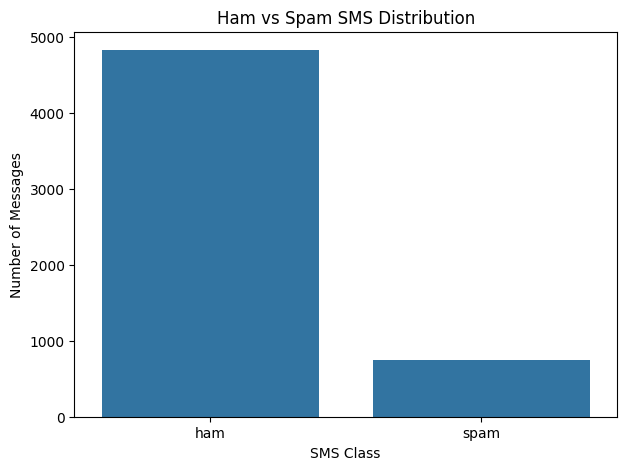

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=data,
    x="label"
)

plt.title("Ham vs Spam SMS Distribution")
plt.xlabel("SMS Class")
plt.ylabel("Number of Messages")

plt.show()

In [ ]:
data[
    ["label", "message"]
].sample(
    10,
    random_state=42
)

,label,message
3245,ham,"Funny fact Nobody teaches volcanoes 2 erupt, t..."
944,ham,I sent my scores to sophas and i had to do sec...
1044,spam,We know someone who you know that fancies you....
2484,ham,Only if you promise your getting out as SOON a...
812,spam,Congratulations ur awarded either å£500 of CD ...
2973,ham,"I'll text carlos and let you know, hang on"
2991,ham,K.i did't see you.:)k:)where are you now?
2942,ham,No message..no responce..what happend?
230,ham,Get down in gandhipuram and walk to cross cut ...
1181,ham,You flippin your shit yet?


In [ ]:
print(data.isnull().sum())

label      0
message    0
dtype: int64


In [ ]:
data = data.dropna(
    subset=["message", "label"]
).reset_index(drop=True)

print(
    "Dataset size:",
    len(data)
)

Dataset size: 5572


In [ ]:
data["char_length"] = data["message"].apply(
    len
)

print(
    "Minimum SMS length:",
    data["char_length"].min()
)

print(
    "Maximum SMS length:",
    data["char_length"].max()
)

print(
    "Average SMS length:",
    data["char_length"].mean()
)

Minimum SMS length: 2
Maximum SMS length: 910
Average SMS length: 80.11880832735105


In [ ]:
data["word_count"] = data["message"].apply(
    lambda x: len(x.split())
)

print(
    "Average words per SMS:",
    data["word_count"].mean()
)

Average words per SMS: 15.494436468054559


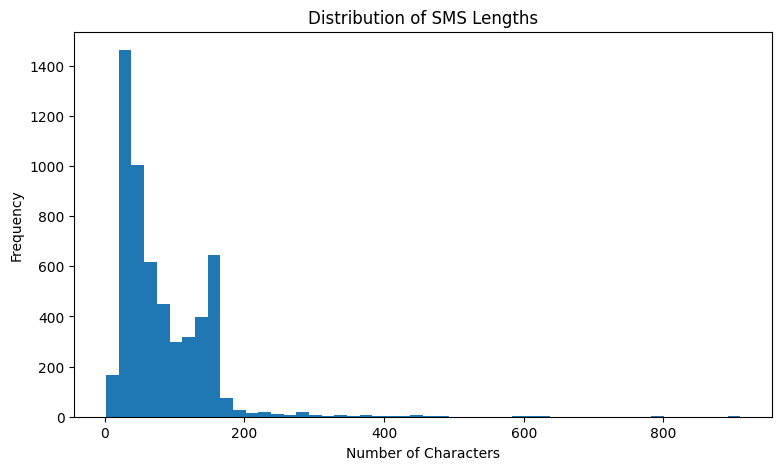

In [ ]:
plt.figure(figsize=(9, 5))

plt.hist(
    data["char_length"],
    bins=50
)

plt.title("Distribution of SMS Lengths")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.show()

In [ ]:
def clean_text(text):

    # Convert text to lowercase
    text = text.lower()

    # Replace multiple spaces with a single space
    text = re.sub(r"\s+", " ", text)

    # Remove leading and trailing spaces
    text = text.strip()

    return text

In [ ]:
data["clean_message"] = data["message"].apply(
    clean_text
)

data[
    ["message", "clean_message"]
].head(10)

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...","go until jurong point, crazy.. available only ..."
1,Ok lar... Joking wif u oni...,ok lar... joking wif u oni...
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...
3,U dun say so early hor... U c already then say...,u dun say so early hor... u c already then say...
4,"Nah I don't think he goes to usf, he lives aro...","nah i don't think he goes to usf, he lives aro..."
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey there darling it's been 3 week's n...
6,Even my brother is not like to speak with me. ...,even my brother is not like to speak with me. ...
7,As per your request 'Melle Melle (Oru Minnamin...,as per your request 'melle melle (oru minnamin...
8,WINNER!! As a valued network customer you have...,winner!! as a valued network customer you have...
9,Had your mobile 11 months or more? U R entitle...,had your mobile 11 months or more? u r entitle...


In [ ]:
print(
    "Duplicate messages:",
    data["clean_message"].duplicated().sum()
)

Duplicate messages: 415


In [ ]:
data = data.drop_duplicates(
    subset=["clean_message"]
).reset_index(drop=True)

print(
    "Dataset size after duplicate removal:",
    len(data)
)

Dataset size after duplicate removal: 5157


In [ ]:
data["label_num"] = data["label"].map({
    "ham": 0,
    "spam": 1
})

data[
    ["label", "label_num"]
].head(10)

,label,label_num
0,ham,0
1,ham,0
2,spam,1
3,ham,0
4,ham,0
5,spam,1
6,ham,0
7,ham,0
8,spam,1
9,spam,1


In [ ]:
X = data["clean_message"].values
y = data["label_num"].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5157,)
y shape: (5157,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(
    "Training samples:",
    len(X_train)
)

print(
    "Testing samples:",
    len(X_test)
)

Training samples: 4125
Testing samples: 1032


In [ ]:
print("Training class distribution:")
print(
    pd.Series(y_train).value_counts()
)

print("\nTesting class distribution:")
print(
    pd.Series(y_test).value_counts()
)

Training class distribution:
0    3611
1     514
Name: count, dtype: int64

Testing class distribution:
0    904
1    128
Name: count, dtype: int64


In [ ]:
VOCAB_SIZE = 5000
MAX_LEN = 50

print("Vocabulary Size:", VOCAB_SIZE)
print("Maximum Sequence Length:", MAX_LEN)

Vocabulary Size: 5000
Maximum Sequence Length: 50


In [ ]:
tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

print(
    "Total words in tokenizer vocabulary:",
    len(tokenizer.word_index)
)

Total words in tokenizer vocabulary: 7830


In [ ]:
X_train_sequences = tokenizer.texts_to_sequences(
    X_train
)

X_test_sequences = tokenizer.texts_to_sequences(
    X_test
)

print("Original SMS:")
print(X_train[0])

print("\nToken IDs:")
print(X_train_sequences[0])

Original SMS:
haha okay... today weekend leh...

Token IDs:
[213, 385, 89, 352, 386]


In [ ]:
X_train_padded = pad_sequences(
    X_train_sequences,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_padded = pad_sequences(
    X_test_sequences,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print(
    "Training shape:",
    X_train_padded.shape
)

print(
    "Testing shape:",
    X_test_padded.shape
)

Training shape: (4125, 50)
Testing shape: (1032, 50)


In [ ]:
sample_index = 0

print("ORIGINAL SMS:")
print(X_train[sample_index])

print("\nTOKENS:")
print(
    tokenizer.sequences_to_texts(
        [X_train_sequences[sample_index]]
    )[0]
)

print("\nTOKEN IDs:")
print(X_train_sequences[sample_index])

print("\nPADDED SEQUENCE:")
print(X_train_padded[sample_index])

ORIGINAL SMS:
haha okay... today weekend leh...

TOKENS:
haha okay today weekend leh

TOKEN IDs:
[213, 385, 89, 352, 386]

PADDED SEQUENCE:
[213 385  89 352 386   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0]


In [ ]:
print(
    "Numerical Label:",
    y_train[sample_index]
)

if y_train[sample_index] == 0:
    print("Class: HAM")
else:
    print("Class: SPAM")

Numerical Label: 0
Class: HAM


In [ ]:
EMBED_DIM = 64

LSTM_UNITS = 64

DENSE_UNITS = 64

DROPOUT_RATE = 0.20

LEARNING_RATE = 0.001

BATCH_SIZE = 32

EPOCHS = 10

print("Hybrid 2 Configuration")
print("----------------------")

print("Vocabulary Size:", VOCAB_SIZE)
print("Maximum Sequence Length:", MAX_LEN)
print("Embedding Dimension:", EMBED_DIM)
print("Bi-LSTM Units:", LSTM_UNITS)
print("Dense Units:", DENSE_UNITS)
print("Dropout:", DROPOUT_RATE)
print("Learning Rate:", LEARNING_RATE)
print("Batch Size:", BATCH_SIZE)
print("Epochs:", EPOCHS)

Hybrid 2 Configuration
----------------------
Vocabulary Size: 5000
Maximum Sequence Length: 50
Embedding Dimension: 64
Bi-LSTM Units: 64
Dense Units: 64
Dropout: 0.2
Learning Rate: 0.001
Batch Size: 32
Epochs: 10


In [ ]:
class AttentionLayer(Layer):

    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):

        self.W = self.add_weight(
            name="attention_weight",
            shape=(input_shape[-1], 1),
            initializer="glorot_uniform",
            trainable=True
        )

        self.b = self.add_weight(
            name="attention_bias",
            shape=(input_shape[1], 1),
            initializer="zeros",
            trainable=True
        )

        super(AttentionLayer, self).build(
            input_shape
        )

    def call(self, x):

        # Calculate attention scores
        e = tf.tanh(
            tf.matmul(x, self.W) + self.b
        )

        # Convert scores into probabilities
        alpha = tf.nn.softmax(
            e,
            axis=1
        )

        # Weighted sum of hidden states
        context = x * alpha

        context = tf.reduce_sum(
            context,
            axis=1
        )

        return context

In [ ]:
inputs = Input(
    shape=(MAX_LEN,),
    name="Input"
)

# Token Embedding
x = Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBED_DIM,
    name="Embedding"
)(inputs)

# Bidirectional LSTM
x = Bidirectional(
    LSTM(
        LSTM_UNITS,
        return_sequences=True
    ),
    name="Bidirectional_LSTM"
)(x)

# Attention
x = AttentionLayer(
    name="Attention"
)(x)

# Dropout
x = Dropout(
    DROPOUT_RATE,
    name="Dropout"
)(x)

# Dense layer
x = Dense(
    DENSE_UNITS,
    activation="relu",
    name="Dense"
)(x)

# Sigmoid output
outputs = Dense(
    1,
    activation="sigmoid",
    name="Output"
)(x)

hybrid2 = Model(
    inputs=inputs,
    outputs=outputs,
    name="Hybrid_2_BiLSTM_Attention"
)

hybrid2.summary()

Model: "Hybrid_2_BiLSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Embedding (Embedding)           │ (None, 50, 64)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Bidirectional_LSTM              │ (None, 50, 128)        │        66,048 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Attention (AttentionLayer)      │ (None, 128)            │           178 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 394,547 (1.51 MB)

 Trainable params: 394,547 (1.51 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer = Adam(
    learning_rate=LEARNING_RATE
)

hybrid2.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print(
    "Hybrid 2 compiled successfully."
)

Hybrid 2 compiled successfully.


In [ ]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [ ]:
start_time = time.time()

history_hybrid2 = hybrid2.fit(
    X_train_padded,
    y_train,
    validation_split=0.20,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1
)

training_time = time.time() - start_time

print(
    f"\nTraining Time: {training_time:.2f} seconds"
)

Epoch 1/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.9176 - loss: 0.2127 - val_accuracy: 0.9648 - val_loss: 0.1068
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.9870 - loss: 0.0530 - val_accuracy: 0.9842 - val_loss: 0.0593
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.9930 - loss: 0.0254 - val_accuracy: 0.9830 - val_loss: 0.0601
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.9982 - loss: 0.0101 - val_accuracy: 0.9855 - val_loss: 0.0683
Epoch 5/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.9988 - loss: 0.0052 - val_accuracy: 0.9842 - val_loss: 0.0799

Training Time: 24.23 seconds


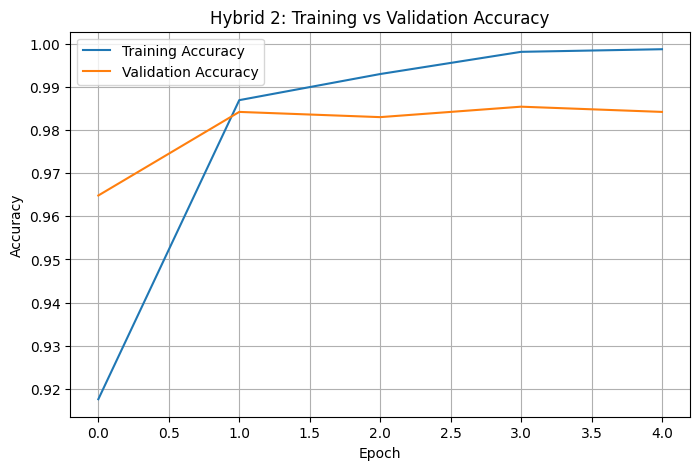

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_hybrid2.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_hybrid2.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Hybrid 2: Training vs Validation Accuracy"
)

plt.legend()
plt.grid(True)

plt.show()

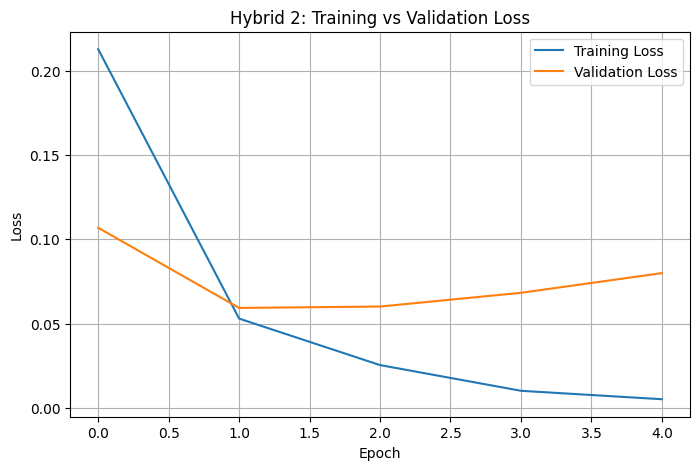

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_hybrid2.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_hybrid2.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Hybrid 2: Training vs Validation Loss"
)

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
test_loss, test_accuracy = hybrid2.evaluate(
    X_test_padded,
    y_test,
    verbose=0
)

print(
    f"Test Loss: {test_loss:.4f}"
)

print(
    f"Test Accuracy: {test_accuracy * 100:.2f}%"
)

Test Loss: 0.0460
Test Accuracy: 98.55%


In [ ]:
start_time = time.time()

y_pred_probability = hybrid2.predict(
    X_test_padded,
    verbose=0
).flatten()

inference_time = time.time() - start_time

# Probability → class
y_pred = (
    y_pred_probability >= 0.5
).astype(int)

print(
    "Predictions generated successfully."
)

print(
    "Prediction shape:",
    y_pred.shape
)

Predictions generated successfully.
Prediction shape: (1032,)


In [ ]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    f"Accuracy: {accuracy:.4f}"
)

print(
    f"Accuracy: {accuracy * 100:.2f}%"
)

Accuracy: 0.9855
Accuracy: 98.55%


In [ ]:
precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

print(
    f"Precision: {precision:.4f}"
)

print(
    f"Precision: {precision * 100:.2f}%"
)

Precision: 0.9748
Precision: 97.48%


In [ ]:
recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

print(
    f"Recall: {recall:.4f}"
)

print(
    f"Recall: {recall * 100:.2f}%"
)

Recall: 0.9062
Recall: 90.62%


In [ ]:
f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

print(
    f"F1-score: {f1:.4f}"
)

print(
    f"F1-score: {f1 * 100:.2f}%"
)

F1-score: 0.9393
F1-score: 93.93%


In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

tn, fp, fn, tp = cm.ravel()

print("True Negative :", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Positive :", tp)

True Negative : 901
False Positive: 3
False Negative: 12
True Positive : 116


<Figure size 700x600 with 0 Axes>

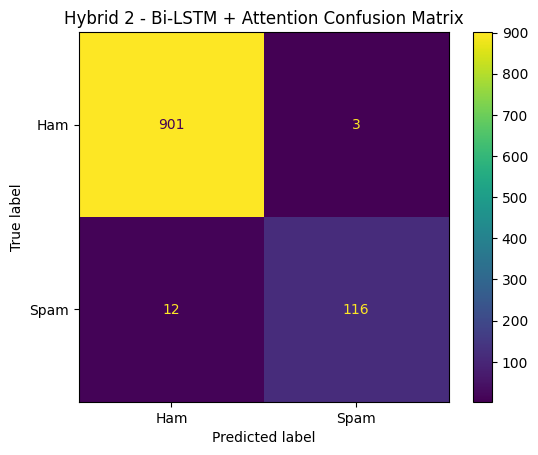

In [ ]:
plt.figure(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Ham", "Spam"]
)

disp.plot()

plt.title(
    "Hybrid 2 - Bi-LSTM + Attention Confusion Matrix"
)

plt.show()

In [ ]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Ham", "Spam"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

         Ham       0.99      1.00      0.99       904
        Spam       0.97      0.91      0.94       128

    accuracy                           0.99      1032
   macro avg       0.98      0.95      0.97      1032
weighted avg       0.99      0.99      0.99      1032



In [ ]:
specificity = tn / (tn + fp)

print(
    f"Specificity: {specificity:.4f}"
)

print(
    f"Specificity: {specificity * 100:.2f}%"
)

Specificity: 0.9967
Specificity: 99.67%


In [ ]:
fpr_value = fp / (fp + tn)

print(
    f"False Positive Rate: {fpr_value:.4f}"
)

print(
    f"False Positive Rate: {fpr_value * 100:.2f}%"
)

False Positive Rate: 0.0033
False Positive Rate: 0.33%


In [ ]:
fnr_value = fn / (fn + tp)

print(
    f"False Negative Rate: {fnr_value:.4f}"
)

print(
    f"False Negative Rate: {fnr_value * 100:.2f}%"
)

False Negative Rate: 0.0938
False Negative Rate: 9.38%


In [ ]:
macro_precision = precision_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

weighted_f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print(
    f"Macro Precision: {macro_precision:.4f}"
)

print(
    f"Macro Recall:    {macro_recall:.4f}"
)

print(
    f"Macro F1:        {macro_f1:.4f}"
)

print(
    f"Weighted F1:     {weighted_f1:.4f}"
)

Macro Precision: 0.9808
Macro Recall:    0.9515
Macro F1:        0.9655
Weighted F1:     0.9852


In [ ]:
roc_auc = roc_auc_score(
    y_test,
    y_pred_probability
)

print(
    f"ROC-AUC: {roc_auc:.4f}"
)

ROC-AUC: 0.9952


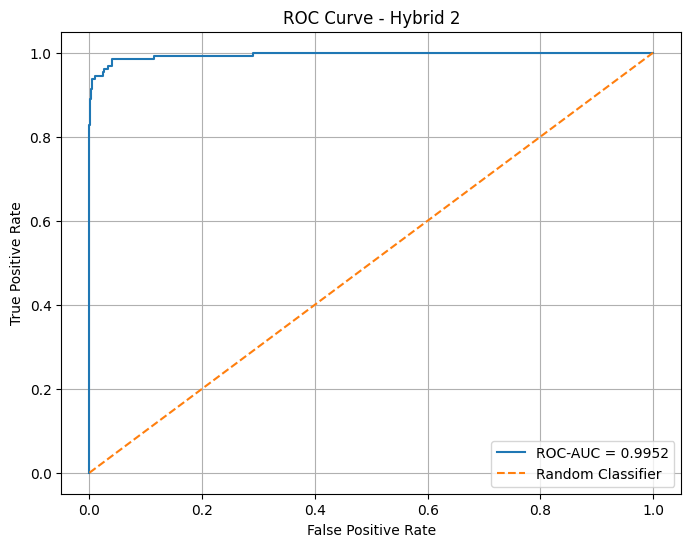

In [ ]:
fpr_curve, tpr_curve, roc_thresholds = roc_curve(
    y_test,
    y_pred_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_curve,
    tpr_curve,
    label=f"ROC-AUC = {roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve - Hybrid 2"
)

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
precision_curve, recall_curve, pr_thresholds = (
    precision_recall_curve(
        y_test,
        y_pred_probability
    )
)

pr_auc = auc(
    recall_curve,
    precision_curve
)

print(
    f"PR-AUC: {pr_auc:.4f}"
)

PR-AUC: 0.9814


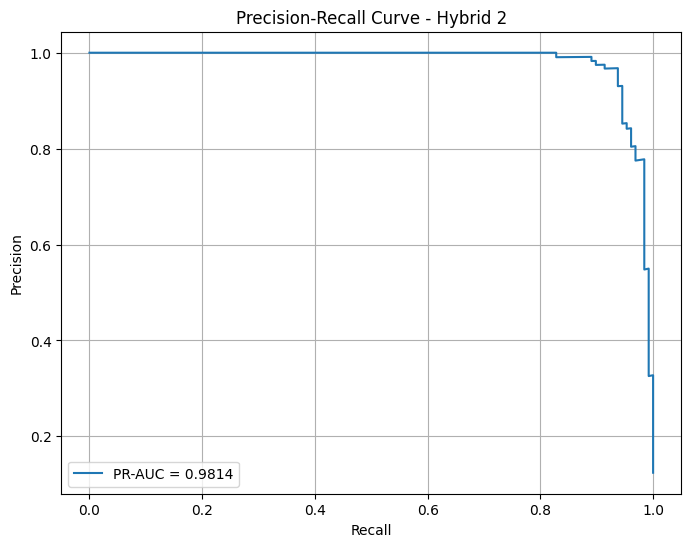

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(
    recall_curve,
    precision_curve,
    label=f"PR-AUC = {pr_auc:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision-Recall Curve - Hybrid 2"
)

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
mcc = matthews_corrcoef(
    y_test,
    y_pred
)

print(
    f"MCC: {mcc:.4f}"
)

MCC: 0.9318


In [ ]:
kappa = cohen_kappa_score(
    y_test,
    y_pred
)

print(
    f"Cohen's Kappa: {kappa:.4f}"
)

Cohen's Kappa: 0.9310


In [ ]:
kappa = cohen_kappa_score(
    y_test,
    y_pred
)

print(
    f"Cohen's Kappa: {kappa:.4f}"
)

Cohen's Kappa: 0.9310


In [ ]:
logloss = log_loss(
    y_test,
    y_pred_probability
)

print(
    f"Log Loss: {logloss:.4f}"
)

Log Loss: 0.0460


In [ ]:
brier = brier_score_loss(
    y_test,
    y_pred_probability
)

print(
    f"Brier Score: {brier:.4f}"
)

Brier Score: 0.0113


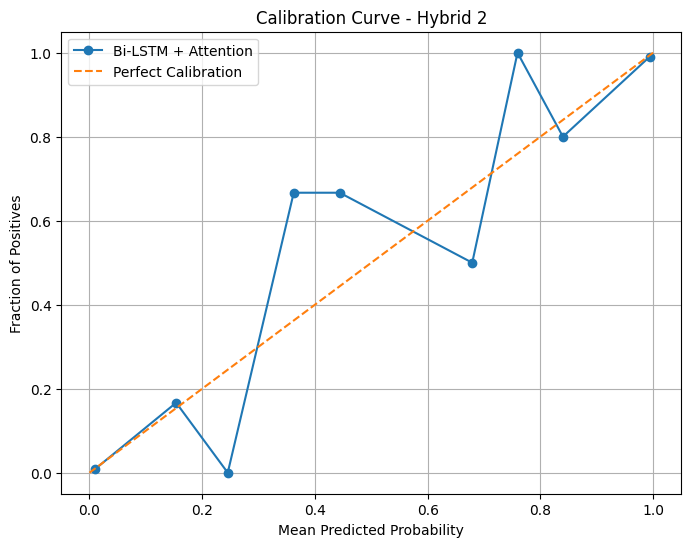

In [ ]:
prob_true, prob_pred = calibration_curve(
    y_test,
    y_pred_probability,
    n_bins=10
)

plt.figure(figsize=(8, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="Bi-LSTM + Attention"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel(
    "Mean Predicted Probability"
)

plt.ylabel(
    "Fraction of Positives"
)

plt.title(
    "Calibration Curve - Hybrid 2"
)

plt.legend()
plt.grid(True)

plt.show()